# Week 6


# Lecture 11: Support Vector Machines

Support vector machines (SVMs) classify points by constructing a separating boundary with the widest possible **margin**. We will connect four versions of this idea to `scikit-learn`:

1. a maximum-margin classifier for linearly separable data;
2. a soft-margin classifier for overlapping data;
3. the kernel trick;
4. kernel SVMs for nonlinear class boundaries.

We will finish by comparing linear, polynomial, and radial-basis-function SVMs on the Breast Cancer and MNIST datasets.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_breast_cancer, make_blobs, make_circles, make_moons
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC


## Separating hyperplanes and support vectors

For a binary problem, encode the labels as $y_i\in\{-1,1\}$. A hyperplane is the set

$$\theta^T x+b=0.$$

The sign of $\theta^Tx+b$ determines the predicted class:

$$\widehat y=\operatorname{sign}(\theta^Tx+b).$$

Many hyperplanes may classify a separable dataset perfectly. An SVM selects the one with the widest margin. After fixing the scale so the nearest observations satisfy $y_i(\theta^Tx_i+b)=1$, the margin width is $2/\lVert\theta\rVert$. The closest observations are the **support vectors**; they determine the boundary.


## Linearly separable case

For perfectly separable training data, the hard-margin problem is

$$\min_{\theta,b}\frac{1}{2}\lVert\theta\rVert^2
\quad\text{subject to}\quad
y_i(\theta^Tx_i+b)\geq 1\quad\text{for every }i.$$

`SVC(kernel='linear', C=...)` fits this classifier. Scikit-learn uses the soft-margin formulation for all finite values of `C`; a very large `C` closely approximates the hard-margin solution when the data are separable. `support_vectors_` returns the points on or inside the margin.


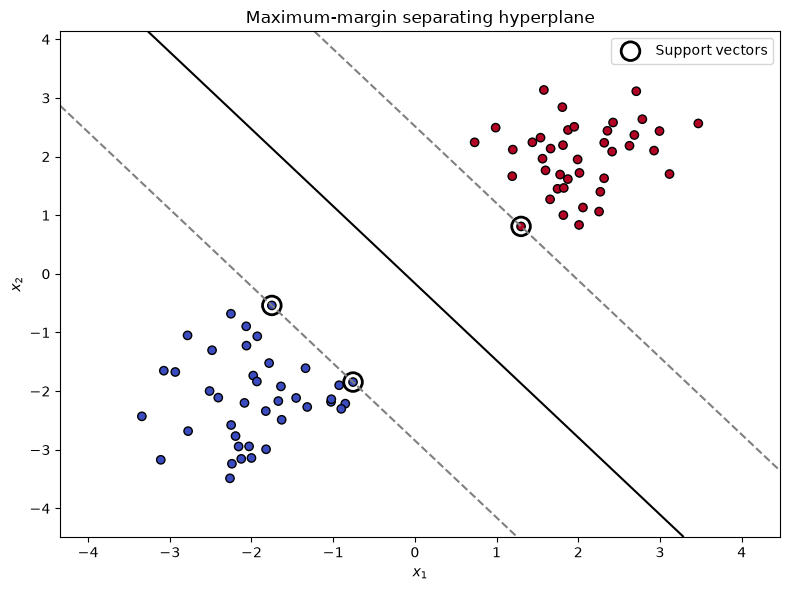

Support vectors per class: [2 1]
Training accuracy: 1.0


In [2]:
X_linear, y_linear = make_blobs(
    n_samples=80, centers=[(-2, -2), (2, 2)], cluster_std=0.65, random_state=7
)

hard_margin = SVC(kernel='linear', C=1e6)
hard_margin.fit(X_linear, y_linear)

fig, ax = plt.subplots(figsize=(8, 6))
DecisionBoundaryDisplay.from_estimator(
    hard_margin, X_linear, response_method='decision_function',
    plot_method='contour', levels=[-1, 0, 1],
    colors=['gray', 'black', 'gray'], linestyles=['--', '-', '--'], ax=ax
)
ax.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, cmap='coolwarm', edgecolor='black')
ax.scatter(hard_margin.support_vectors_[:, 0], hard_margin.support_vectors_[:, 1],
           s=180, facecolors='none', edgecolors='black', linewidths=2,
           label='Support vectors')
ax.set_title('Maximum-margin separating hyperplane')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()
plt.tight_layout()
plt.show()

print('Support vectors per class:', hard_margin.n_support_)
print('Training accuracy:', hard_margin.score(X_linear, y_linear))


## Soft-margin SVM: linearly nonseparable data

Real classes often overlap. Slack variables $\xi_i\geq0$ allow observations to enter the margin or cross the boundary:

$$\min_{\theta,b,\xi}\frac{1}{2}\lVert\theta\rVert^2+C\sum_i\xi_i
\quad\text{subject to}\quad
y_i(\theta^Tx_i+b)\geq1-\xi_i.$$

The `C` argument controls the tradeoff:

* large `C`: penalize violations strongly, producing a narrower margin that follows training data more closely;
* small `C`: tolerate more violations, producing stronger regularization and a wider margin.

Feature scaling matters because the margin and penalty depend on distances. We therefore put `StandardScaler` and the classifier in one pipeline.


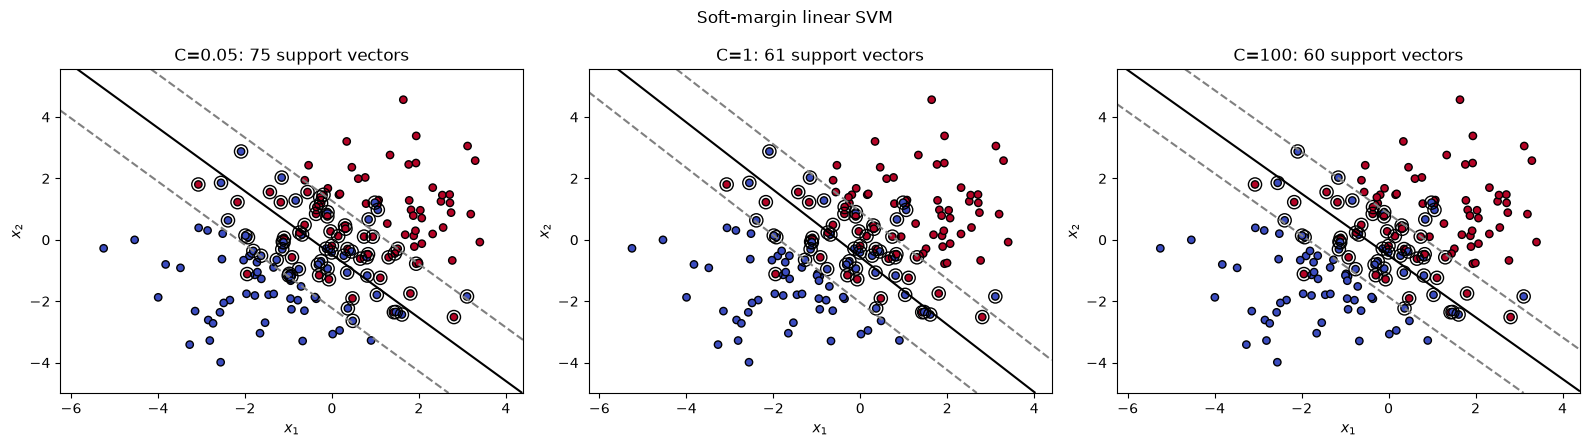

In [3]:
X_overlap, y_overlap = make_blobs(
    n_samples=160, centers=[(-1, -1), (1, 1)], cluster_std=1.35, random_state=12
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, C in zip(axes, [0.05, 1, 100]):
    model = SVC(kernel='linear', C=C)
    model.fit(X_overlap, y_overlap)
    DecisionBoundaryDisplay.from_estimator(
        model, X_overlap, response_method='decision_function',
        plot_method='contour', levels=[-1, 0, 1],
        colors=['gray', 'black', 'gray'], linestyles=['--', '-', '--'], ax=ax
    )
    ax.scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_overlap,
               cmap='coolwarm', edgecolor='black', s=28)
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=90, facecolors='none', edgecolors='black')
    ax.set_title(f'C={C}: {model.n_support_.sum()} support vectors')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
fig.suptitle('Soft-margin linear SVM')
fig.tight_layout()
plt.show()


## The kernel trick

A nonlinear transformation $\phi(x)$ can make classes linearly separable in a new feature space. The SVM optimization only needs inner products

$$\phi(x)^T\phi(z).$$

A **kernel** computes this value directly:

$$K(x,z)=\phi(x)^T\phi(z).$$

This is the kernel trick: use a high-dimensional feature space without explicitly constructing all transformed variables. Common scikit-learn choices are

* `kernel='linear'`: $K(x,z)=x^Tz$;
* `kernel='poly'`: $K(x,z)=(\gamma x^Tz+r)^d$;
* `kernel='rbf'`: $K(x,z)=\exp(-\gamma\lVert x-z\rVert^2)$.

For a polynomial kernel, `degree` is $d$ and `coef0` is $r$. For an RBF kernel, large `gamma` creates narrow, local influence and a more flexible boundary; small `gamma` creates a smoother boundary. `gamma='scale'` is a useful default based on the number and variance of the inputs.


## Seeing the kernel idea: lifting 2D points into 3D

Concentric classes cannot be separated by a line in the original $(x_1,x_2)$ plane. Consider the explicit nonlinear feature map

$$\phi(x_1,x_2)=\left(x_1,x_2,x_1^2+x_2^2\right).$$

The third coordinate is squared distance from the origin. Inner-circle observations receive small values and outer-circle observations receive large values. In this three-dimensional feature space, a horizontal plane

$$z=c$$

separates the classes. A polynomial kernel provides these kinds of products and squared terms without requiring us to construct and store every transformed variable ourselves.


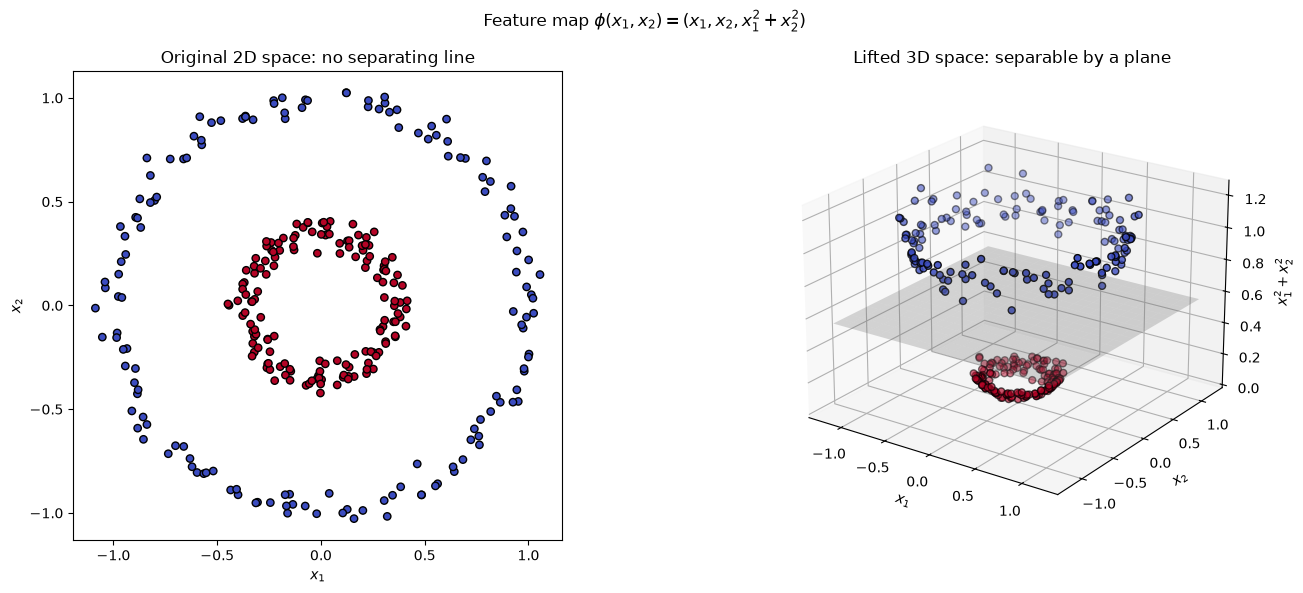

In [4]:
X_lift, y_lift = make_circles(
    n_samples=300, factor=0.35, noise=0.04, random_state=11
)
radius_squared = np.sum(X_lift ** 2, axis=1)
X_lifted = np.column_stack((X_lift, radius_squared))

# Put the plane halfway between the average squared radii of the classes.
plane_height = np.mean([
    radius_squared[y_lift == 0].mean(),
    radius_squared[y_lift == 1].mean(),
])

fig = plt.figure(figsize=(15, 6))

ax_2d = fig.add_subplot(1, 2, 1)
ax_2d.scatter(X_lift[:, 0], X_lift[:, 1], c=y_lift,
              cmap='coolwarm', edgecolor='black', s=28)
ax_2d.set_xlabel('$x_1$')
ax_2d.set_ylabel('$x_2$')
ax_2d.set_title('Original 2D space: no separating line')
ax_2d.set_aspect('equal')

ax_3d = fig.add_subplot(1, 2, 2, projection='3d')
ax_3d.scatter(X_lifted[:, 0], X_lifted[:, 1], X_lifted[:, 2],
              c=y_lift, cmap='coolwarm', edgecolor='black', s=25)

grid = np.linspace(-1.2, 1.2, 20)
plane_x, plane_y = np.meshgrid(grid, grid)
plane_z = np.full_like(plane_x, plane_height)
ax_3d.plot_surface(plane_x, plane_y, plane_z, alpha=0.25, color='gray')
ax_3d.set_xlabel('$x_1$')
ax_3d.set_ylabel('$x_2$')
ax_3d.set_zlabel('$x_1^2+x_2^2$')
ax_3d.set_title('Lifted 3D space: separable by a plane')
ax_3d.view_init(elev=22, azim=-55)

fig.suptitle(r'Feature map $\phi(x_1,x_2)=(x_1,x_2,x_1^2+x_2^2)$')
fig.tight_layout()
plt.show()


## Kernel SVM: the nonlinear case

The following data form two curved moons. No single line can separate them, so we compare linear, quadratic-polynomial, and RBF kernels using the same train/test split.


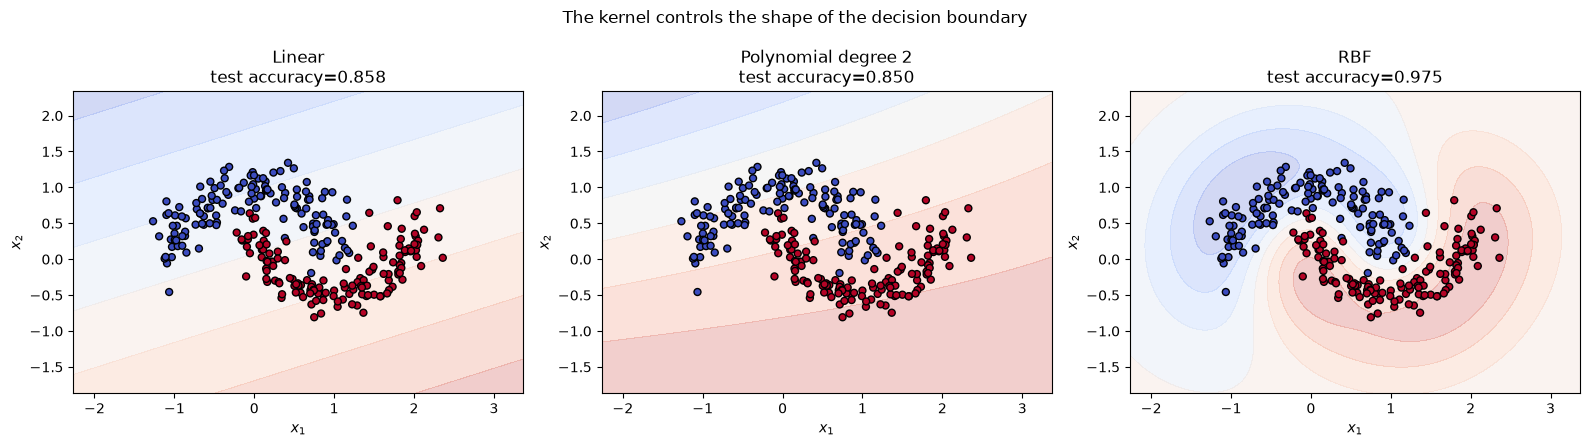

In [5]:
X_moons, y_moons = make_moons(n_samples=400, noise=0.18, random_state=7)
trainX, testX, trainY, testY = train_test_split(
    X_moons, y_moons, test_size=0.30, stratify=y_moons, random_state=7
)

kernel_models = {
    'Linear': SVC(kernel='linear', C=1),
    'Polynomial degree 2': SVC(kernel='poly', degree=2, coef0=1, C=2, gamma='scale'),
    'RBF': SVC(kernel='rbf', C=2, gamma='scale'),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, model) in zip(axes, kernel_models.items()):
    model.fit(trainX, trainY)
    DecisionBoundaryDisplay.from_estimator(
        model, X_moons, response_method='decision_function',
        plot_method='contourf', alpha=0.25, cmap='coolwarm', ax=ax
    )
    ax.scatter(trainX[:, 0], trainX[:, 1], c=trainY,
               cmap='coolwarm', edgecolor='black', s=25)
    ax.set_title(f'{name}\ntest accuracy={model.score(testX, testY):.3f}')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
fig.suptitle('The kernel controls the shape of the decision boundary')
fig.tight_layout()
plt.show()


## How `C` and `gamma` interact

For an RBF SVM, `C` controls tolerance for classification violations while `gamma` controls how local each observation's influence is. We visualize both effects on concentric-circle data.


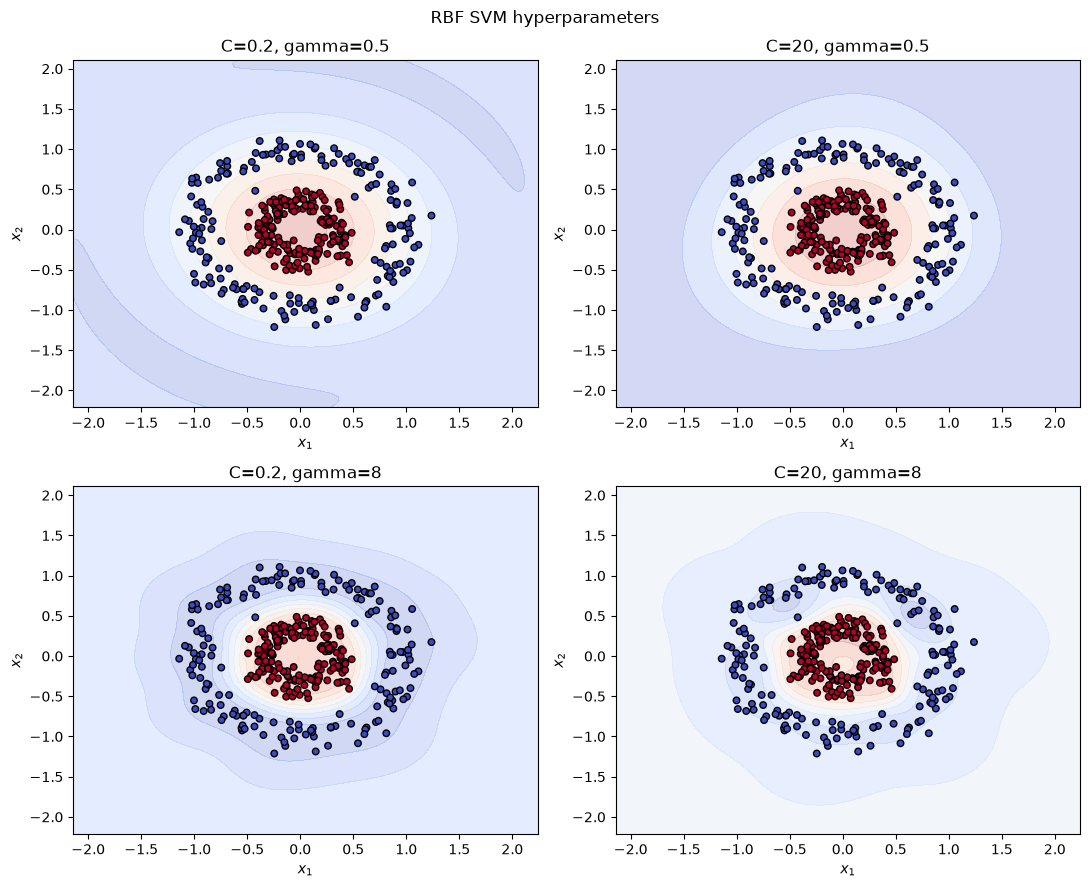

In [6]:
X_circles, y_circles = make_circles(
    n_samples=350, factor=0.35, noise=0.10, random_state=7
)

settings = [(0.2, 0.5), (20, 0.5), (0.2, 8), (20, 8)]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (C, gamma) in zip(axes.ravel(), settings):
    model = SVC(kernel='rbf', C=C, gamma=gamma).fit(X_circles, y_circles)
    DecisionBoundaryDisplay.from_estimator(
        model, X_circles, response_method='decision_function',
        plot_method='contourf', alpha=0.25, cmap='coolwarm', ax=ax
    )
    ax.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles,
               cmap='coolwarm', edgecolor='black', s=22)
    ax.set_title(f'C={C}, gamma={gamma}')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
fig.suptitle('RBF SVM hyperparameters')
fig.tight_layout()
plt.show()


## Breast Cancer classification

The Breast Cancer dataset is binary with 30 numerical variables. We compare:

* `LinearSVC`: an efficient soft-margin linear classifier;
* `SVC(kernel='linear')`: a linear SVM that also exposes support vectors;
* polynomial and RBF kernel SVMs.

Every model uses the same standardized training and testing observations. `class_weight='balanced'` makes each class contribute inversely to its frequency.


In [7]:
cancer = load_breast_cancer()
trainX, testX, trainY, testY = train_test_split(
    cancer.data, cancer.target, test_size=0.25,
    stratify=cancer.target, random_state=7
)

cancer_models = {
    'LinearSVC': LinearSVC(C=1, class_weight='balanced', dual='auto', max_iter=20000),
    'Linear kernel': SVC(kernel='linear', C=1, class_weight='balanced'),
    'Polynomial kernel': SVC(kernel='poly', degree=2, coef0=1, C=1,
                             gamma='scale', class_weight='balanced'),
    'RBF kernel': SVC(kernel='rbf', C=2, gamma='scale', class_weight='balanced'),
}

fitted_cancer_models = {}
for name, classifier in cancer_models.items():
    model = make_pipeline(StandardScaler(), classifier)
    model.fit(trainX, trainY)
    fitted_cancer_models[name] = model
    print(f'{name:20s} train={model.score(trainX, trainY):.3f}  test={model.score(testX, testY):.3f}')


LinearSVC            train=0.986  test=0.965
Linear kernel        train=0.991  test=0.979
Polynomial kernel    train=0.986  test=0.972
RBF kernel           train=0.986  test=0.965


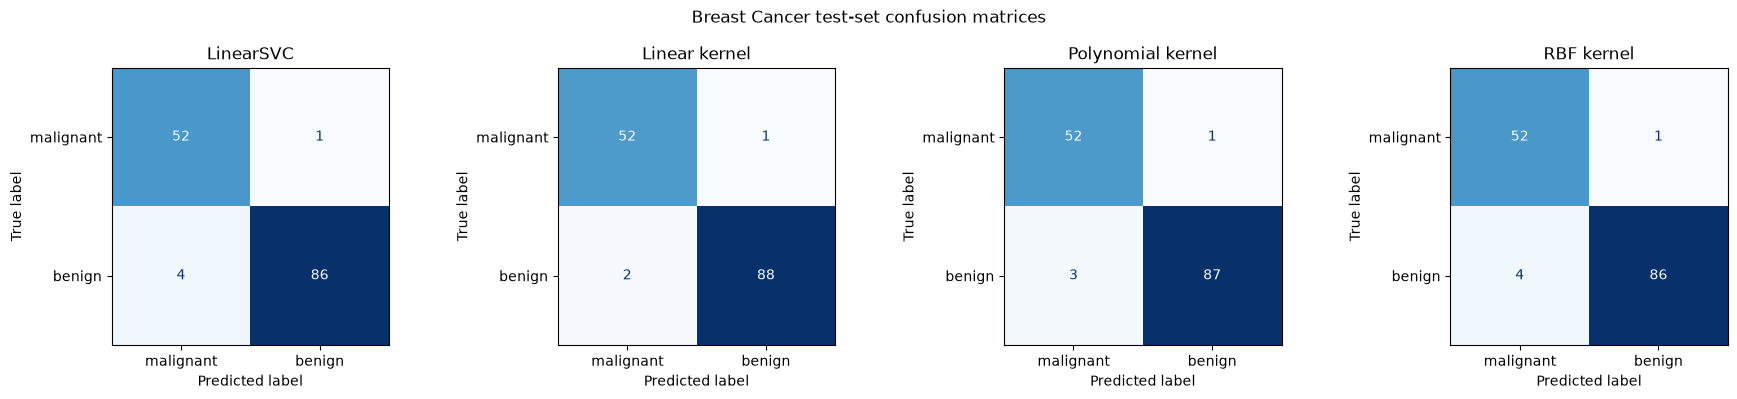

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, model) in zip(axes, fitted_cancer_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, testX, testY, display_labels=cancer.target_names,
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(name)
fig.suptitle('Breast Cancer test-set confusion matrices')
fig.tight_layout()
plt.show()


## MNIST handwritten digits

MNIST contains 28-by-28 grayscale images. Flattening an image gives 784 input variables. We scale pixel intensities to $[0,1]$ and use a reproducible subset so all four SVM variants run in a reasonable amount of class time.

Multiclass `SVC` fits one classifier for every pair of classes. `LinearSVC` uses a one-versus-rest strategy. The `decision_function_shape` argument controls only the reported decision-score layout for `SVC`; training remains one-versus-one.


In [9]:
from tensorflow.keras.datasets import mnist

(mnist_trainX, mnist_trainY), (mnist_testX, mnist_testY) = mnist.load_data()

mnist_trainX = mnist_trainX.reshape(len(mnist_trainX), -1).astype('float32') / 255
mnist_testX = mnist_testX.reshape(len(mnist_testX), -1).astype('float32') / 255

# A fixed stratified subset keeps nonlinear SVM training practical.
mnist_trainX, _, mnist_trainY, _ = train_test_split(
    mnist_trainX, mnist_trainY, train_size=12000,
    stratify=mnist_trainY, random_state=7
)
mnist_testX, _, mnist_testY, _ = train_test_split(
    mnist_testX, mnist_testY, train_size=3000,
    stratify=mnist_testY, random_state=7
)

mnist_models = {
    'LinearSVC': LinearSVC(C=0.1, dual='auto', max_iter=20000),
    'Linear kernel': SVC(kernel='linear', C=1),
    'Polynomial kernel': SVC(kernel='poly', degree=3, C=5, gamma='scale'),
    'RBF kernel': SVC(kernel='rbf', C=5, gamma='scale'),
}

mnist_predictions = {}
for name, model in mnist_models.items():
    model.fit(mnist_trainX, mnist_trainY)
    prediction = model.predict(mnist_testX)
    mnist_predictions[name] = prediction
    print(f'{name:20s} accuracy={accuracy_score(mnist_testY, prediction):.3f}')


I0000 00:00:1786812247.523945  115684 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


LinearSVC            accuracy=0.902
Linear kernel        accuracy=0.916
Polynomial kernel    accuracy=0.960
RBF kernel           accuracy=0.972


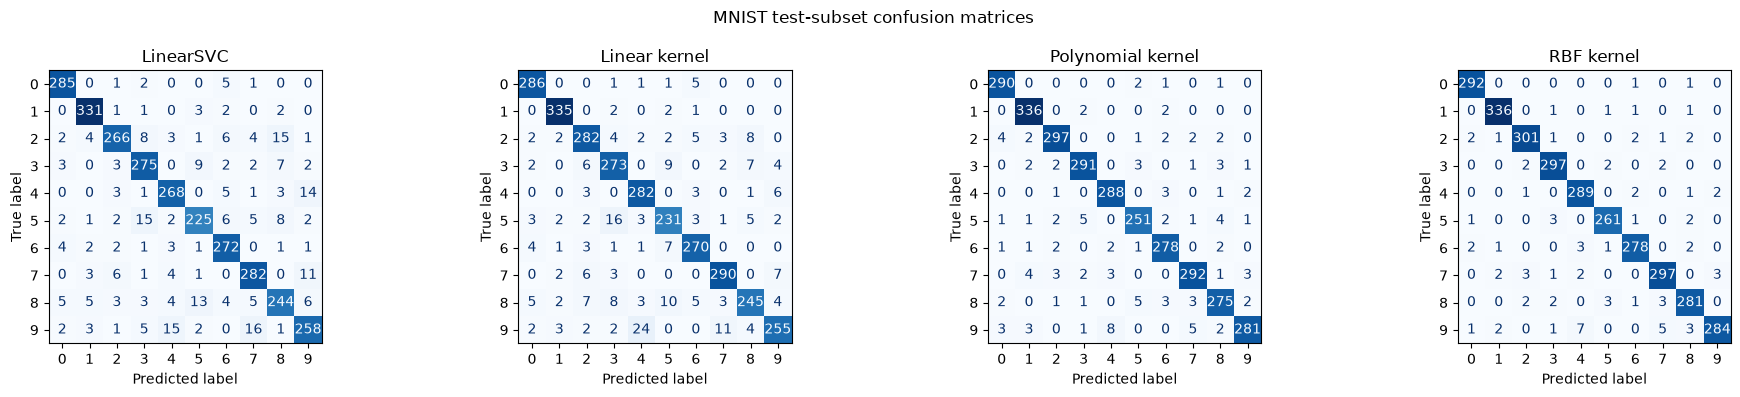

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4))
for ax, (name, prediction) in zip(axes, mnist_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        mnist_testY, prediction, cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(name)
fig.suptitle('MNIST test-subset confusion matrices')
fig.tight_layout()
plt.show()


## Summary: mathematics to scikit-learn

| Mathematical idea | Scikit-learn choice |
|:---|:---|
| Linear score $\theta^Tx+b$ | `kernel='linear'` or `LinearSVC` |
| Approximate hard margin | `SVC(kernel='linear', C=very_large)` on separable data |
| Soft-margin penalty $C\sum_i\xi_i$ | `C`; smaller means more regularization |
| Polynomial kernel $(\gamma x^Tz+r)^d$ | `kernel='poly'`, `gamma`, `coef0=r`, `degree=d` |
| RBF kernel $e^{-\gamma\lVert x-z\rVert^2}$ | `kernel='rbf'`, `gamma` |
| Distance-based geometry | Standardize inputs, preferably in a `Pipeline` |
| Margin-defining observations | `SVC.support_vectors_` and `SVC.n_support_` |

Choose the kernel and hyperparameters with validation data or cross-validation—not with the test set. Use the test set once for the final estimate of performance.


# Lecture 12: Nearest Neighbors

The $k$-nearest neighbor classifier tries to classify numerical examples into categories. Suppose we have some labeled examples $x_1, ..., x_n\in\mathbb{R}^d$ with labels $y_1, ..., y_n$. If we have a new, unlabeled point $x$, we would like to predict its class label. The idea of the $k$-nearest neighbor algorithm is that we take the $k$ labeled examples nearest to $x$ and assign the most frequent class of these nearest "neighbors" to $x$.

## The Procedure to Classify an Example $x$ with $k$-Nearest Neighbors

1. Choose a positive integer for $k$.

1. Find the distances $\left\|x-x_j\right\|$ for each $j=1,...,n$ with any norm you choose.

1. Find the points with the $k$ shortest distances from $x$ (the $k$ nearest "neighbors").

1. Assign the most frequent class among the $k$ nearest neighbors to $x$

This means we need to make only two decisions two use the $k$-nearest neighbors: we need to choose a norm and we need to choose the number of neighbors $k$ to use. Customizable parameters for a machine learning method like this $k$-nearest neighbor classifier are called **hyperparameters**. It is not generally obvious how to choose these hyperparameters and it tends to be pretty experimental. Tuning hyperparameters is a large part of machine learning.

## $k$-Nearest Neighbor Code

Let's write some code. I will use the style used by the popular machine learning library <a href="https://scikit-learn.org/stable/">scikit-learn</a>, where a classifier is written as a class in the programming sense (not to be confused with the "classes" of our classification problem) with hyperparameters as inputs. The classifier's class will have some functions that fit the model to the data and predict the class of input datapoints.

The `fit` function for the $k$-nearest neighbors will do very little but record some data. The 'predict' function will carry out steps 1-4 above.

First, we import some libraries.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn

from scipy.stats import mode
from sklearn import datasets
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.datasets import mnist

In [6]:
# Create a class for the k-nearest neighbor classifier
class kNearestNeighborClassifier:
    # constructor to save the hyperparameter k
    def __init__(self, k = 5):
        # initialize the number of neighbors to use
        self.neighbors = k
    
    # fit the model to the training data (for kNN, there's no actual fitting involved)
    def fit(self, X, y):
            
        # record the data and labels
        self.data = X
        self.labels = y
    
    # use the classifier to predict the classifications of the testing data
    def predict(self, X):
        # initialize the predicted classes
        yPredicted = np.empty([X.shape[0],1])
        
        # loop over the datapoints in X
        for row in range(X.shape[0]):
            datapoint = X[row,]
            
            # find the distances from the datapoint to each training point using the L2 norm
            distances = np.sqrt(np.sum(((self.data - datapoint)**2), axis = 1))
            
            # find the indices of the smallest k distances
            indices = np.argsort(distances)[:self.neighbors]
            
            # find the the class labels of the nearest neighbors
            nearestClasses = self.labels[indices]
            
            # determine the predicted class by finding the mode
            yPredicted[row] = int(mode(nearestClasses, keepdims=False).mode)
            
        return yPredicted

## Example: Randomly Generated Points

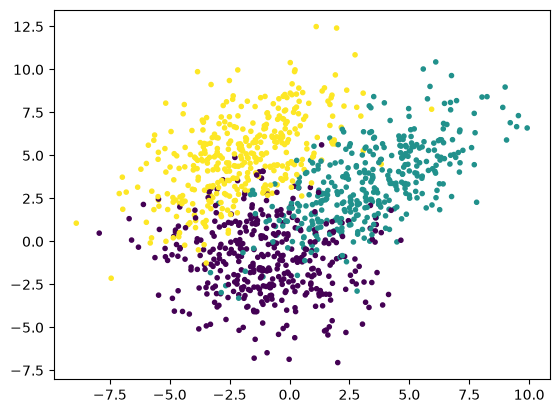

In [7]:
# number of points to generate
numberOfPoints = 500

# generate points from class 0
mean1 = np.array([-1, -1])
covariance1 = np.array([[5, 0], [0, 5]])
X1 = np.random.multivariate_normal(mean1, covariance1, numberOfPoints)

# generate points from class 1
mean2 = np.array([3, 3])
covariance2 = np.array([[5, 3], [3, 5]])
X2 = np.random.multivariate_normal(mean2, covariance2, numberOfPoints)

# generate points from class 2
mean3 = np.array([-2, 5])
covariance3 = np.array([[5, 3], [3, 5]])
X3 = np.random.multivariate_normal(mean3, covariance3, numberOfPoints)

# stack the points
X = np.vstack((X1, X2, X3))

# create a vector of the labels
Y = np.hstack((numberOfPoints * [0], numberOfPoints * [1], numberOfPoints * [2]))

# randomly choose 75% of the data to be the training set and 25% for the testing set
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25, random_state = 1)

# plot the training set
plt.scatter(trainX[:,0], trainX[:,1], c = trainY, marker = '.')


Classification Report:

               precision    recall  f1-score   support

           0       0.76      0.78      0.77       120
           1       0.87      0.79      0.83       127
           2       0.85      0.90      0.87       128

    accuracy                           0.82       375
   macro avg       0.82      0.82      0.82       375
weighted avg       0.83      0.82      0.82       375


Confusion Matrix:



<Axes: >

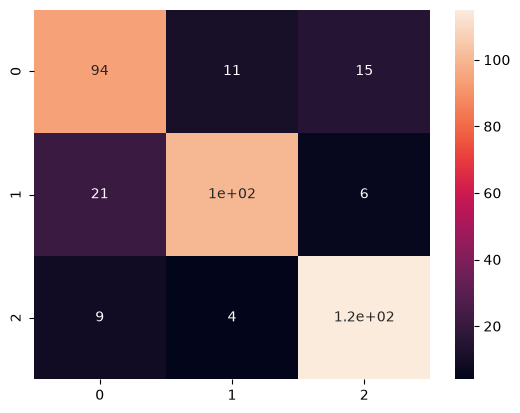

In [8]:
# fit the model to the training data
model = kNearestNeighborClassifier(k = 3)
model.fit(trainX,trainY)

# predict the labels of the test set
predictedY = model.predict(testX)

plt.scatter(trainX[:,0], trainX[:,1], c = trainY, marker = '.')

# print quality metrics
print('\nClassification Report:\n\n', classification_report(testY, predictedY))
print('\nConfusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY), annot = True)

The code above computes the neighbors in a pretty brute-force way, which is pretty slow, so it is generally best to use an existing implementation like `KNeighborsClassifier` in `scikit-learn`.


Classification Report:

               precision    recall  f1-score   support

           0       0.76      0.78      0.77       120
           1       0.87      0.79      0.83       127
           2       0.85      0.90      0.87       128

    accuracy                           0.82       375
   macro avg       0.82      0.82      0.82       375
weighted avg       0.83      0.82      0.82       375


Confusion Matrix:



<Axes: >

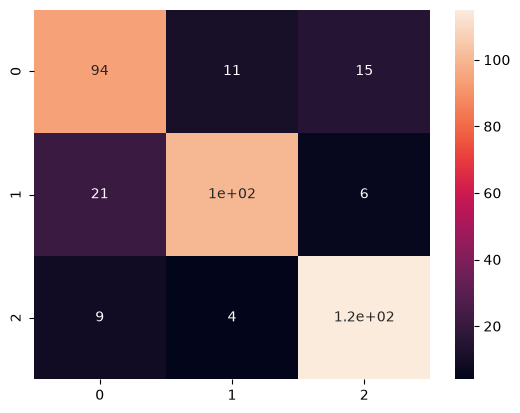

In [9]:
# fit the model to the training data
model = KNeighborsClassifier(3)
model.fit(trainX,trainY)

# predict the labels of the test set
predictedY = model.predict(testX)

plt.scatter(trainX[:,0], trainX[:,1], c = trainY, marker = '.')

# print quality metrics
print('\nClassification Report:\n\n', classification_report(testY, predictedY))
print('\nConfusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY), annot = True)


Classification Report:

               precision    recall  f1-score   support

           0       0.77      0.80      0.78       120
           1       0.87      0.79      0.83       127
           2       0.86      0.91      0.88       128

    accuracy                           0.83       375
   macro avg       0.83      0.83      0.83       375
weighted avg       0.83      0.83      0.83       375


Confusion Matrix:



<Axes: >

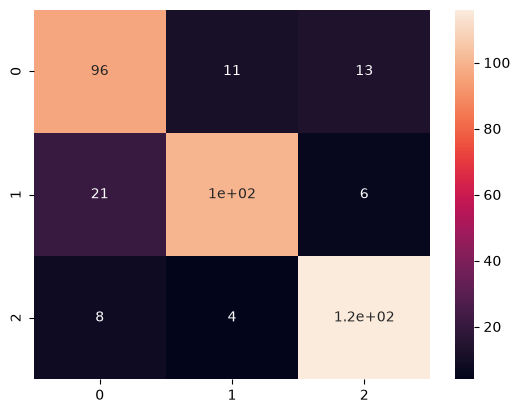

In [10]:
# fit the model to the training data
model = KNeighborsClassifier(n_neighbors = 3, weights = 'distance')
model.fit(trainX,trainY)

# predict the labels of the test set
predictedY = model.predict(testX)

plt.scatter(trainX[:,0], trainX[:,1], c = trainY, marker = '.')

# print quality metrics
print('\nClassification Report:\n\n', classification_report(testY, predictedY))
print('\nConfusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY), annot = True)

## Classifying MNIST Handwritten Digits with $k$-NN

Dev classification accuracy 1 neighbors is 0.86
Dev classification accuracy 2 neighbors is 0.858
Dev classification accuracy 3 neighbors is 0.878
Dev classification accuracy 4 neighbors is 0.872
Dev classification accuracy 5 neighbors is 0.867
Dev classification accuracy 6 neighbors is 0.865
Dev classification accuracy 7 neighbors is 0.863
Dev classification accuracy 8 neighbors is 0.862
Dev classification accuracy 9 neighbors is 0.861
Dev classification accuracy 10 neighbors is 0.854

The best dev accuracy 0.878 occured with 3 neghbors

Test Classification Report for 0.878 neighbors:

               precision    recall  f1-score   support

           0       0.91      0.99      0.95        91
           1       0.77      1.00      0.87        89
           2       0.94      0.78      0.85       116
           3       0.87      0.88      0.87        96
           4       0.85      0.81      0.83        91
           5       0.86      0.77      0.81       104
           6       0.96    

<Axes: >

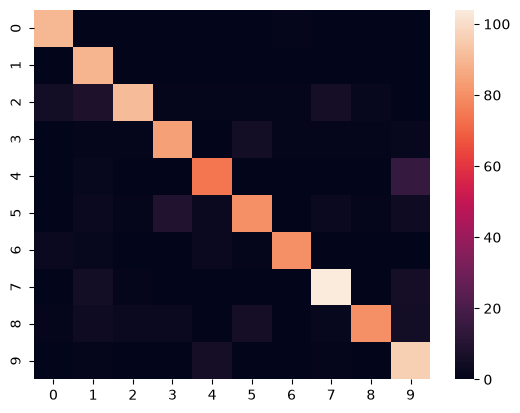

In [11]:
(trainX, trainY), (testX, testY) = mnist.load_data()

trainX = trainX.reshape(trainX.shape[0], trainX.shape[1] * trainX.shape[2]).astype('float')/255.0
testX = testX.reshape(testX.shape[0], testX.shape[1] * testX.shape[2]).astype('float')/255.0

devX, testX, devY, testY = train_test_split(testX, testY, test_size = 0.5)

trainX = trainX[:1000]
devX = devX[:1000]
testX = testX[:1000]
trainY = trainY[:1000]
devY = devY[:1000]
testY = testY[:1000]

bestAccuracy = [0, 0]

for k in range(1, 11):
    # build the knn classifier
    model = KNeighborsClassifier(k)

    # fit the knn classifier to the training data
    model.fit(trainX, trainY)

    # predict the labels of the test set
    predictedY = model.predict(devX)
    
    # compute the accuracy
    acc = accuracy_score(devY, predictedY)
    
    # print quality metrics
    print('Dev classification accuracy', k, 'neighbors is', acc)
    
    # save the hyperparameter k if better than found before
    if acc > bestAccuracy[0]:
        bestAccuracy = [acc, k]
        
print('\nThe best dev accuracy', bestAccuracy[0], 'occured with', bestAccuracy[1], 'neghbors')
        
# build the knn classifier
model = KNeighborsClassifier(bestAccuracy[1])

# fit the knn classifier to the training data
model.fit(trainX, trainY)

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTest Classification Report for', bestAccuracy[0], 'neighbors:\n\n', classification_report(testY, predictedY))
print('\nTest Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))

Mean CV accuracy for 1 neighbors is 0.9393
Mean CV accuracy for 2 neighbors is 0.9307000000000001
Mean CV accuracy for 3 neighbors is 0.9395000000000001
Mean CV accuracy for 4 neighbors is 0.9405000000000001
Mean CV accuracy for 5 neighbors is 0.9377000000000001
Mean CV accuracy for 6 neighbors is 0.9362999999999999
Mean CV accuracy for 7 neighbors is 0.9359999999999999
Mean CV accuracy for 8 neighbors is 0.9343999999999999
Mean CV accuracy for 9 neighbors is 0.9345000000000001
Mean CV accuracy for 10 neighbors is 0.9341000000000002

The best dev accuracy 0.9405000000000001 occured with 4 neghbors

Test Classification Report for 0.9405000000000001 neighbors:

               precision    recall  f1-score   support

           0       0.94      0.99      0.96       980
           1       0.91      0.99      0.95      1135
           2       0.97      0.92      0.95      1032
           3       0.92      0.95      0.94      1010
           4       0.96      0.95      0.95       982
      

<Axes: >

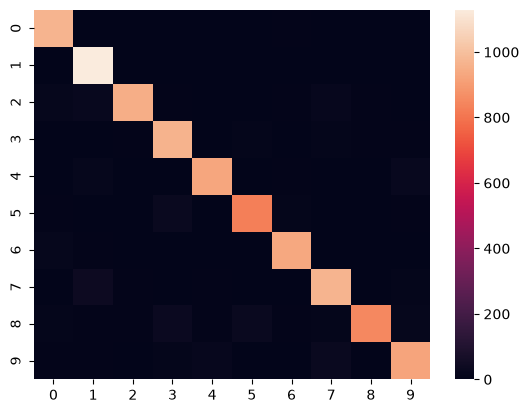

In [12]:
(trainX, trainY), (testX, testY) = mnist.load_data()

trainX = trainX.reshape(trainX.shape[0], trainX.shape[1] * trainX.shape[2]).astype('float')/255.0
testX = testX.reshape(testX.shape[0], testX.shape[1] * testX.shape[2]).astype('float')/255.0

trainX = trainX[:10000]
testX = testX[:10000]
trainY = trainY[:10000]
testY = testY[:10000]

bestAccuracy = [0, 0]

for k in range(1, 11):
    # build the knn classifier
    model = KNeighborsClassifier(k)

    # fit the knn classifier to the training data
    model.fit(trainX, trainY)
    
    mean_cv_scores = np.mean(cross_val_score(model, trainX, trainY, cv = 5))

    # print quality metrics
    print('Mean CV accuracy for', k, 'neighbors is', mean_cv_scores)
    
    # save the hyperparameter k if better than found before
    if mean_cv_scores > bestAccuracy[0]:
        bestAccuracy = [mean_cv_scores, k]
        
print('\nThe best dev accuracy', bestAccuracy[0], 'occured with', bestAccuracy[1], 'neghbors')
        
# build the knn classifier
model = KNeighborsClassifier(bestAccuracy[1])

# fit the knn classifier to the training data
model.fit(trainX, trainY)

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTest Classification Report for', bestAccuracy[0], 'neighbors:\n\n', classification_report(testY, predictedY))
print('\nTest Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))

This is quite good accuracy at 94%!